# **Adversarial Attack on Neural Network** 

Sofía Maldonado García

This small activity aims at making an adversarial attack using an original image of a Chichuahua, and making it think it is something else.

The Chihuahua has an ID of **151** in ImageNet

In [1]:
# Imports
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import resnet50
import numpy as np
import json

Loading image, and applying transformation for imagenet

In [2]:
KIRA_ID = 151

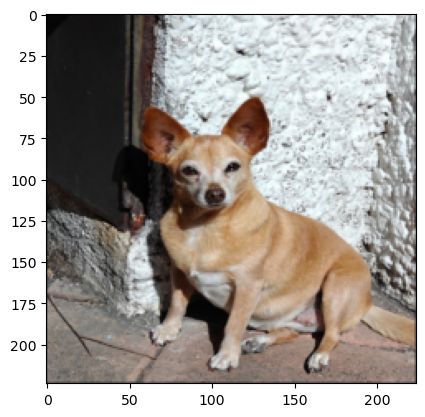

In [3]:
kira_img = Image.open('kira.png')
preprocess = transforms.Compose([
   transforms.Resize((224,224)),
   transforms.ToTensor(),
])
kira_tensor = preprocess(kira_img)[None,:,:,:]

plt.imshow(kira_tensor[0].numpy().transpose(1,2,0))

Esta es Kira, mi mascota :)

#### Baseline

In [4]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.mean = torch.Tensor(mean)
        self.std = torch.Tensor(std)
    def forward(self, x):
        return (x - self.mean.type_as(x)[None,:,None,None]) / self.std.type_as(x)[None,:,None,None]

norm = Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

model = resnet50(pretrained=True)
model.eval()

/home/sofi/miniconda3/envs/mnlpp/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sofi/miniconda3/envs/mnlpp/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
5.5%

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/sofi/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [5]:
pred = model(norm(kira_tensor))

In [6]:
with open("imagenet_class_index.json") as f:
    imagenet_classes = {int(i):x[1] for i,x in json.load(f).items()}
print(imagenet_classes[pred.max(dim=1)[1].item()])

Chihuahua


The baseline predicts my dog correctly as a chihuahua.

In [7]:
foo = nn.CrossEntropyLoss()(model(norm(kira_tensor)),torch.LongTensor([KIRA_ID])).item()
print(foo)
print(np.exp(-foo))

0.025965631008148193
0.9743685770989674


In [8]:
import torch.optim as optim
epsilon = 0.25/255

delta = torch.zeros_like(kira_tensor, requires_grad=True)
opt = optim.SGD([delta], lr=1e-1)

for t in range(30):
    pred = model(norm(kira_tensor + delta))
    loss = -nn.CrossEntropyLoss()(pred, torch.LongTensor([KIRA_ID]))
    if t % 5 == 0:
        print(t, loss.item())

    opt.zero_grad()
    loss.backward()
    opt.step()
    delta.data.clamp_(-epsilon, epsilon)

print("True class probability:", nn.Softmax(dim=1)(pred)[0,KIRA_ID].item())

0 -0.025965631008148193
5 -1.2925883531570435
10 -1.4856098890304565
15 -1.4132353067398071
20 -1.5284119844436646
25 -1.4208958148956299
True class probability: 0.218180313706398


In [9]:
max_class = pred.max(dim=1)[1].item()
print("Predicted class: ", imagenet_classes[max_class])
print("Predicted probability:", nn.Softmax(dim=1)(pred)[0,max_class].item())

Predicted class:  dingo
Predicted probability: 0.6925204992294312


It now predicts my dog as a Dingo. In my testing, the smallest E value that can trick the model into changing its prediction is 1/1020, or 0.00098039215

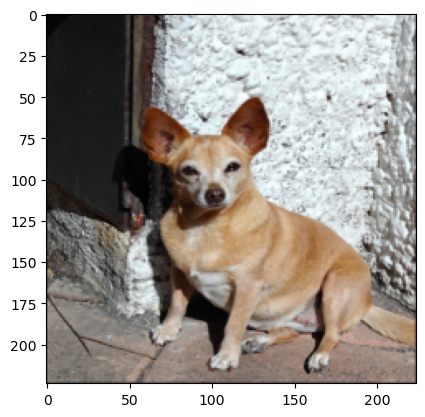

In [10]:
plt.imshow((kira_tensor + delta)[0].detach().numpy().transpose(1,2,0))

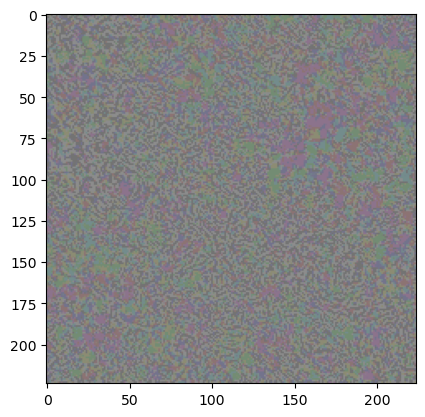

In [11]:
plt.imshow((50*delta+0.5)[0].detach().numpy().transpose(1,2,0))

In this test, the adversarial attack worked, and made the model think the image was a dingo. This makes sense, as these are two very similar animals.

<img src='kira.png' width= '300'>

<img src='https://media.australian.museum/media/dd/images/Some_image.width-800.d97ce05.jpg' width='300'>